In [234]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from email.utils import parsedate_to_datetime
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [235]:
df = pd.read_csv('dataset_cleaned.csv', nrows=35000)

**Features in the raw dataset, before processing:**

- Standard gmail fields:
    - Message-ID                 
    - From                       
    - To                         
    - Date                       
    - List (if sent to a mailing list, empty otherwise)
    - Subject                    
    - Labels                     
- Derived features: 
    - IsInTrash (based on the labels)                  
    - IsUnread (based on the labels) 
- Text readability analysis, based on standard library textstat package
    - ReadabilityEase  (textstat.flesch_reading_ease of message body, higher = easier (0-100))          
    - ReadabilityKincaidGrade (textstat.flesch_kincaid_grade of message body, represents US school grade level education needed to understand the text)
    - ReadabilityGunningFog  (textstat.gunning_fog of message body, estimates years of formal education needed to understand the text)
- Text tone analysis, based on https://github.com/sloria/textblob 
    - polarity  (blob.sentiment.polarity,  -1.0 (Negative) to +1.0 (Positive))
    - subjectivity (blob.sentiment.subjectivity, 0.0 (Objective) to 1.0 (Subjective))

I decided not to do the prediction of message "deletability" that I previously considered because I did not have enough training data in the dataset to predict this specific feature. Instead, I decided to test whether the selected features are sufficient to predict the author of an email (the From column).
I also decided to drop the "Topic" feature created by the BERTTopic package that I considered including in the initial stages of this project. This was due to a large cardinality of topics (too many per email to be useful or encodable numerically). 

In [236]:

## remove redundant or unneeded columns
remove = ['Message-ID', 'Subject', 'Labels']
df.drop(columns=remove, inplace=True)

## remove sent emails as the exercise is to guess the external senders
df = df[~(df['From'].str.contains('Misha Avrekh'))]

## tranform from and to email addresses to numerical values
label_encoder_from = LabelEncoder()
df['From'] = label_encoder_from.fit_transform(df['From'])

label_encoder_to = LabelEncoder()
df['To'] = label_encoder_to.fit_transform(df['To'])

## transform datetime stamp for each email to Unix time (seconds since January 1, 1970). Cast to int to remove trailing decimals. Drop the original Date column
df['Unixtime'] = df['Date'].apply(
    lambda x: int(parsedate_to_datetime(x).timestamp()) if pd.notna(x) else None
)
df.drop(columns=['Date'], inplace=True)

## transform List to 1 or 0 depending on whether there is an email list value
df['List'] = df['List'].fillna(0)
df['List'] = df['List'].apply(
    lambda x: 1 if x != 0 and x != "" else 0
)

## fill in any missing values with zeroes. At this point, this should only apply to the readability and tone scores for multipart messages
df = df.fillna(0)

## distributions:
print(df.count())
print(df['From'].value_counts().head(15))
print(df['To'].value_counts().head(15))


From                       27576
To                         27576
List                       27576
IsInTrash                  27576
IsUnread                   27576
ReadabilityEase            27576
ReadabilityKincaidGrade    27576
ReadabilityGunningFog      27576
polarity                   27576
subjectivity               27576
Unixtime                   27576
dtype: int64
From
307     1879
1711    1552
1233    1397
1876     995
2787     748
1202     376
1178     344
2477     343
1996     267
1935     240
1555     231
1744     217
1716     215
1170     202
830      182
Name: count, dtype: int64
To
2019    5847
1321    4678
1616    2782
322     1371
735      487
2314     449
1948     383
1916     382
238      378
321      353
2304     332
749      316
449      296
1309     223
2280     211
Name: count, dtype: int64


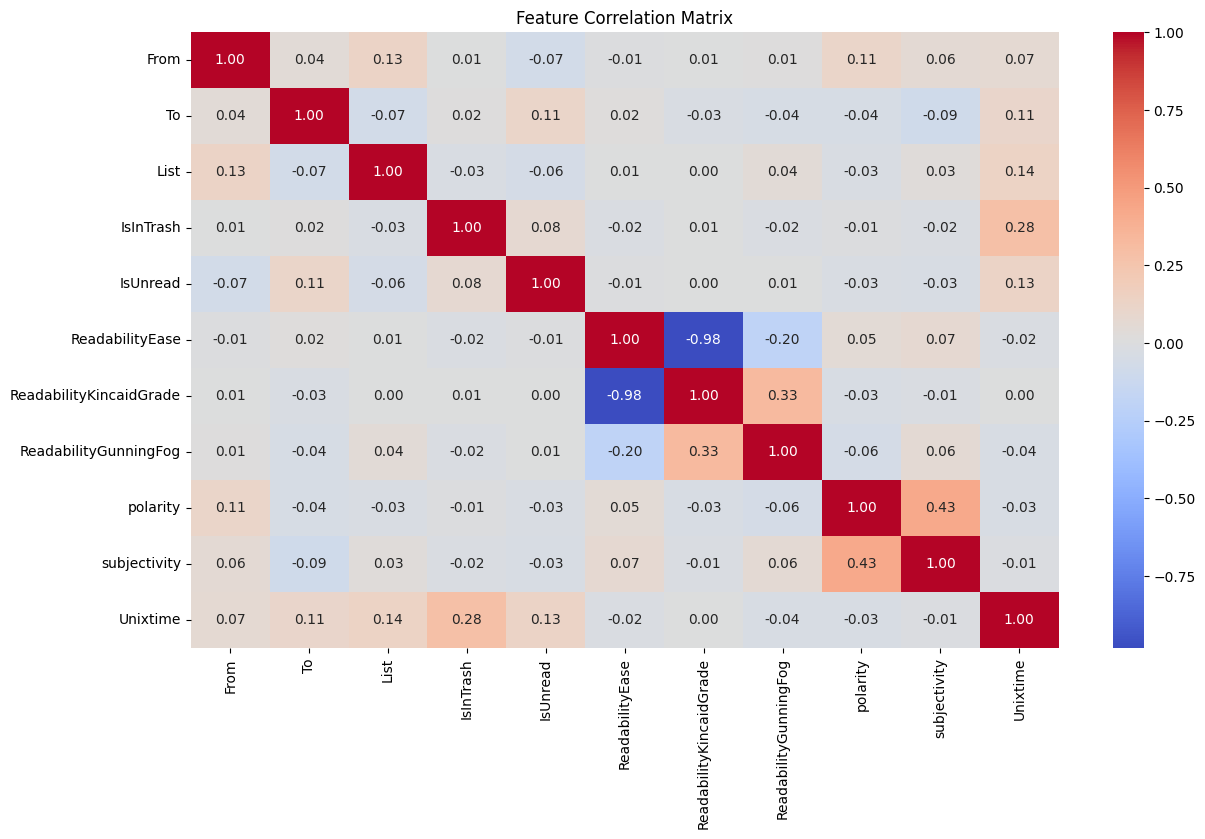

In [237]:
plt.figure(figsize=(14, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

*ReadabilityKincaidGrade* and *ReadabilityEase* have a correlation coefficient of -0.98. Let's drop one or the other.

In [238]:
df.drop(columns=['ReadabilityKincaidGrade'], inplace=True)

In [239]:
# Prepare data first
include_top_X = 10

# Filter to top X senders first, otherwise there are too many
top_X = df['From'].value_counts().nlargest(include_top_X).index
df_top_X_senders = df[df['From'].isin(top_X)].copy()

X = df_top_X_senders.drop(columns=['From'])
y = df_top_X_senders['From']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [240]:
## Random Forest training
print("\nRandom Forest Results:")
rf = RandomForestClassifier(n_estimators=500, min_samples_leaf=10, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


Random Forest Results:


Random Forest Accuracy: 0.794924273434302
Classification Report:
               precision    recall  f1-score   support

         307       0.99      1.00      1.00       543
        1178       0.72      0.50      0.59       106
        1202       0.82      0.86      0.84       108
        1233       0.64      0.79      0.71       431
        1711       0.67      0.72      0.69       481
        1876       0.94      0.95      0.94       295
        1935       0.50      0.03      0.05        80
        1996       0.62      0.31      0.41        74
        2477       0.95      0.90      0.92       105
        2787       0.77      0.75      0.76       220

    accuracy                           0.79      2443
   macro avg       0.76      0.68      0.69      2443
weighted avg       0.79      0.79      0.78      2443

Confusion Matrix:

Index([307, 1711, 1233, 1876, 2787, 1202, 1178, 2477, 1996, 1935], dtype='int64', name='From')
[[543   0   0   0   0   0   0   0   0   0]
 [  0  53   0   6 

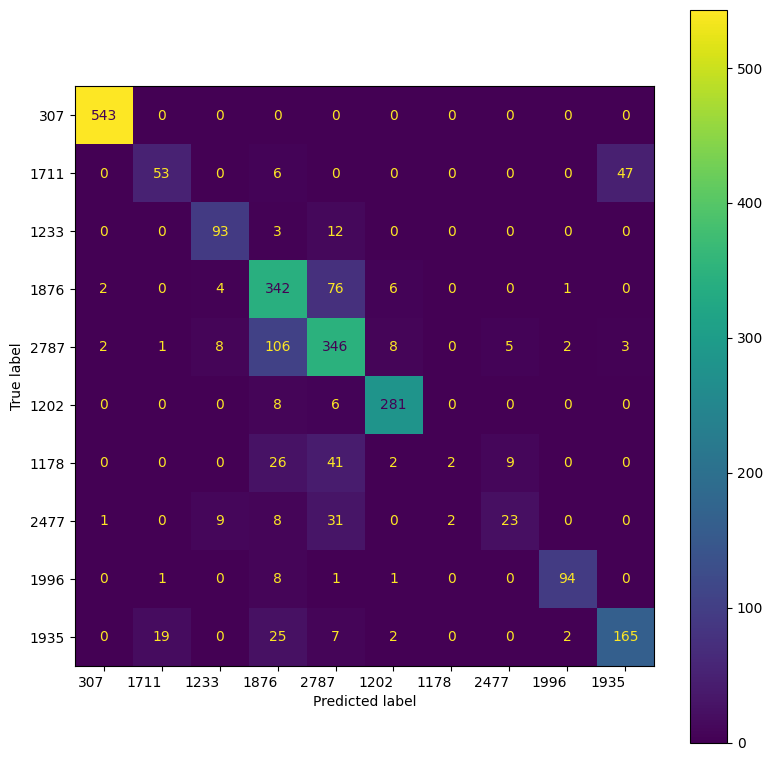

In [241]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n")

cm = confusion_matrix(y_test, y_pred_rf)
print(top_X)
print(cm)

## plot the confusion matrix
_, ax = plt.subplots(figsize=(8, 8))
plt.setp(ax.get_xticklabels(), rotation=90, ha='right', rotation_mode='anchor')
plt.tight_layout()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_X) 
disp.plot(ax=ax)
plt.show()

RF accuracy:
- with 300 estimators: 83%
- with 500 estimators: 84%
- increasing the number of estimators beyond 500 did not have any noticeable effect on the accuracy.
- targets with less support have lower accuracy. smoothing out the tail of the training set might help with this.


K-Nearest Neighbors (KNN) Results:
KNN Accuracy: 0.7597216537044618
Classification Report:
               precision    recall  f1-score   support

         307       0.92      1.00      0.96       543
        1178       0.77      0.55      0.64       106
        1202       0.69      0.78      0.73       108
        1233       0.64      0.74      0.68       431
        1711       0.63      0.61      0.62       481
        1876       0.94      0.86      0.90       295
        1935       0.38      0.26      0.31        80
        1996       0.50      0.32      0.39        74
        2477       0.95      0.86      0.90       105
        2787       0.76      0.79      0.77       220

    accuracy                           0.76      2443
   macro avg       0.72      0.68      0.69      2443
weighted avg       0.76      0.76      0.75      2443

Confusion Matrix:

Index([307, 1711, 1233, 1876, 2787, 1202, 1178, 2477, 1996, 1935], dtype='int64', name='From')
[[541   0   0   0   0   2   0   0 

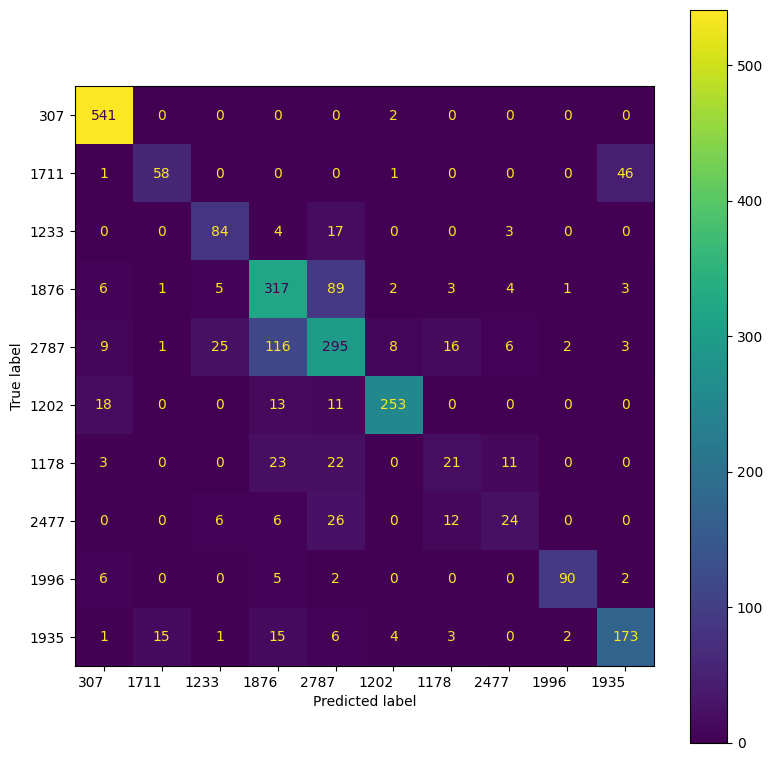

In [242]:
print("\nK-Nearest Neighbors (KNN) Results:")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Classification Report:\n", classification_report(y_test, y_pred_knn))

cm = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n")
print(top_X)
print(cm)

## plot the confusion matrix
_, ax = plt.subplots(figsize=(8, 8))
plt.setp(ax.get_xticklabels(), rotation=90, ha='right', rotation_mode='anchor')
plt.tight_layout()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=top_X) 
disp.plot(ax=ax)
plt.show()

KNN accuracy for comparison with RF:
- with n_neighbors=5: 76%
- with n_neighbors=8: 75%

**Discussion**

The raw dataset has a long tail distribution, where the number of messages per sender drops off exponentially after the top 5 senders. This affects prediction accuracy: even with training the models based on the top ten senders as we do here, there is an almost 10x difference in support between the topmost sender and the 10th most active sender. This can be addressed by using a different model.

The Random Forest model was able to predict the senders based on the text features with an 83-84% accuracy overall. The confusion matrix contains some interesting findings. For example, the greatest number of prediction errors (false positives and false negatives) occurred at the intersections of an academic mailing list I used to read and the emails from my kids' school. This makes sense logically and indicates that the chosed set of features is reasonably descriptive for predicting the sender. There was zero content crossover between these two senders, i.e. no forwards or replies, which likely skewed the predictions for some other senders (some of my top senders likely forwarded or replied to emails from my other top senders and copied me).

Now, let's see if we can do something productive with the long tail of this dataset. Specifically, let's see if we can find any clusters of user behavior based on the available features.

The internet tells me that hdbscan is a useful package for detecting clusters in long-tail distributions.

In [243]:
from sklearn.preprocessing import RobustScaler
import hdbscan

## we dropped the From column in the X set earlier, so let's go back to the full, preprocessed dataframe
X = df

# Scaling: the internet tells me that RobustScaler handles skewed, long-tailed distributions better than the StandardScaler used above
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X)

# HDBSCAN Clustering. min_cluster_size sets the smallest micro-segment to detect
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=2,            # Smallest group size you care to find
    min_samples=1,                 # Crucial: Don't aggressively penalize sparse points
    cluster_selection_epsilon=0.2, # Keeps the normal "head" from shattering
    metric='euclidean',
    cluster_selection_method='eom' # 'Excess of Mass' finds the most distinct densities
)

df['cluster'] = clusterer.fit_predict(X_scaled)

#df['From'] = label_encoder_from.inverse_transform(X['From'])
print(df[['cluster', 'From']].sort_values(by='cluster'))

profiling_metrics = {
    'From':'count',
    'ReadabilityEase': ['mean', 'min', 'max'],
    'polarity': ['mean', 'min', 'max'],
    'subjectivity': ['mean', 'min', 'max']
}
cluster_profiles = df.groupby('cluster').agg(profiling_metrics)

cluster_profiles.columns = [
    'sender_count',
    'avg_readability', 'min_readability', 'max_readability', 
    'avg_polarity', 'min_polarity', 'max_polarity',
    'avg_subjectivity', 'min_subjectivity', 'max_subjectivity'
]

cluster_profiles = cluster_profiles.sort_values(by='sender_count', ascending=False)

# Display the profile table
print("=== CLUSTER PROFILES ===")
print(cluster_profiles.round(3)) ## round all scores to 3 decimal places



       cluster  From
34999       -1  1202
7336        -1  1508
7334        -1   181
20257       -1  3082
20260       -1  3082
...        ...   ...
17846     6070  1744
17938     6070  1711
19648     6070  1711
18009     6070  1744
18335     6070  1744

[27576 rows x 2 columns]
=== CLUSTER PROFILES ===
         sender_count  avg_readability  min_readability  max_readability  \
cluster                                                                    
-1               7684           41.544        -6223.780          121.220   
 3039             663           62.010           55.088           74.479   
 110              146            0.000            0.000            0.000   
 471              144           61.949           53.302           74.479   
 1830             101            3.133          -19.432           25.356   
...               ...              ...              ...              ...   
 2635               2           55.693           53.719           57.668   
 2638        

This breaks up the long tail into clusters by sender based on the email text parameters. If I had more time, I would try to find out who sends the most subjective / emotional emails etc.

Other interesting projects to pursue when time allows:
**The best time to write an email**.

Create four additional features based on the time of day when an email was sent. Something like the following code should work:

```
# Define bins for the hours (0 to 24)
bins = [0, 6, 12, 18, 24]
labels = ['Early Morning', 'Morning', 'Afternoon', 'Night']

# Extract the hour and bin it
df['time_of_day'] = pd.cut(
    pd.to_datetime(df['Unixtime'], unit='s').dt.hour, ## back to datetime from unix time 
    bins=bins, 
    labels=labels, 
    right=False # Ensures 06:00 falls into 'Morning', 12:00 into 'Afternoon', etc.
)
```

Filter out the emails sent to a mailing list, as those are more likely to be scheduled emails, which are not written at the time they are sent.

Analyze the text features like readability, tone, etc. based on the time of day when an email was sent. Find optimal times for writing a subjective email (for example).
